# 02 - TRỰC QUAN HÓA - FTT & S&P 500

## 0. Thiết lập môi trường và tái tạo dữ liệu

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from supabase import create_client

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / ".env").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
load_dotenv(PROJECT_ROOT / ".env")

SUPABASE_URL = os.getenv("SUPABASE_URL")
SUPABASE_KEY = os.getenv("SUPABASE_PUBLISHABLE_KEY")
if not SUPABASE_URL or not SUPABASE_KEY:
    raise RuntimeError("Khong tim thay SUPABASE_URL hoac SUPABASE_PUBLISHABLE_KEY trong .env")

supabase = create_client(SUPABASE_URL, SUPABASE_KEY)
START_DATE = pd.Timestamp("2021-01-01")
END_DATE = pd.Timestamp("2025-01-01")  # exclusive
FTT_TICKER = "FTT-USD"
SP500_TICKER = "^GSPC"

print("Research period:", START_DATE.date(), "->", (END_DATE - pd.Timedelta(days=1)).date())


Matplotlib is building the font cache; this may take a moment.


Research period: 2021-01-01 -> 2024-12-31


In [2]:
def get_asset(ticker):
    response = (
        supabase.table("assets")
        .select("asset_id, ticker, asset_name, asset_type, data_source")
        .eq("ticker", ticker).limit(1).execute()
    )
    if not response.data:
        raise RuntimeError(f"Không tìm thấy asset {ticker} trong bảng assets.")
    return response.data[0]


REQUIRED_COLUMNS = ["price_id", "asset_id", "trade_date", "open_price", "high_price",
                     "low_price", "close_price", "volume", "created_at"]
PAGE_SIZE = 1000


def fetch_daily_prices(asset_id, ticker):
    rows, start = [], 0
    while True:
        response = (
            supabase.table("daily_prices")
            .select("price_id, asset_id, trade_date, open_price, high_price, low_price, close_price, volume, created_at")
            .eq("asset_id", asset_id)
            .gte("trade_date", START_DATE.strftime("%Y-%m-%d"))
            .lt("trade_date", END_DATE.strftime("%Y-%m-%d"))
            .order("trade_date", desc=False)
            .range(start, start + PAGE_SIZE - 1)
            .execute()
        )
        batch = response.data or []
        rows.extend(batch)
        if len(batch) < PAGE_SIZE:
            break
        start += PAGE_SIZE

    df = pd.DataFrame(rows, columns=REQUIRED_COLUMNS)
    if df.empty:
        raise RuntimeError(f"Không có dữ liệu cho {ticker}.")
    df["trade_date"] = pd.to_datetime(df["trade_date"], errors="coerce")
    for col in ["open_price", "high_price", "low_price", "close_price", "volume"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.sort_values("trade_date", kind="stable").reset_index(drop=True)


def preprocess_price_data(df, name):
    data = df.copy()
    data["trade_date"] = pd.to_datetime(data["trade_date"], errors="coerce")
    data = data[data["trade_date"].between(START_DATE, END_DATE - pd.Timedelta(days=1), inclusive="both")].copy()
    data = data.dropna(subset=["trade_date"])
    data = data.sort_values("trade_date", kind="stable")
    data = data.drop_duplicates(subset=["trade_date"], keep="first")
    invalid_close = data["close_price"].isna() | ~np.isfinite(data["close_price"]) | (data["close_price"] <= 0)
    data = data.loc[~invalid_close].reset_index(drop=True)
    return data


def add_returns(df, price_col, prefix, check_daily_continuity=False):
    data = df.copy()
    data[f"{prefix}_simple_return"] = data[price_col].pct_change()
    data[f"{prefix}_log_return"] = np.log(data[price_col] / data[price_col].shift(1))
    if check_daily_continuity:
        day_diff = data["trade_date"].diff().dt.days
        gap_mask = day_diff > 1
        data.loc[gap_mask, [f"{prefix}_simple_return", f"{prefix}_log_return"]] = np.nan
    return data


ftt_asset = get_asset(FTT_TICKER)
sp500_asset = get_asset(SP500_TICKER)

ftt_raw = fetch_daily_prices(ftt_asset["asset_id"], FTT_TICKER)
sp500_raw = fetch_daily_prices(sp500_asset["asset_id"], SP500_TICKER)

ftt_processed = preprocess_price_data(ftt_raw, "FTT")
sp500_processed = preprocess_price_data(sp500_raw, "S&P 500")

ftt_processed = add_returns(ftt_processed, "close_price", "FTT", True)
sp500_processed = add_returns(sp500_processed, "close_price", "SP500", False)

ftt_min = ftt_processed["trade_date"].min().date()
ftt_max = ftt_processed["trade_date"].max().date()
sp_min = sp500_processed["trade_date"].min().date()
sp_max = sp500_processed["trade_date"].max().date()
print(f"FTT processed:    {ftt_processed.shape}  ({ftt_min} -> {ftt_max})")
print(f"S&P500 processed: {sp500_processed.shape}  ({sp_min} -> {sp_max})")


FTT processed:    (1461, 11)  (2021-01-01 -> 2024-12-31)
S&P500 processed: (1005, 11)  (2021-01-04 -> 2024-12-31)


## 0.1. Định nghĩa event window (FTX sụp đổ)

In [3]:
# Event window chính (theo README): FTX sụp đổ 02/11 - 11/11/2022
EVENT_START = pd.Timestamp("2022-11-02")
EVENT_END = pd.Timestamp("2022-11-11")
EVENT_DATE = pd.Timestamp("2022-11-08")  # ngày FTX tạm dừng rút tiền

VIEW_START = pd.Timestamp("2022-10-01")
VIEW_END = pd.Timestamp("2022-12-31")

print("Event window (FTX collapse):", EVENT_START.date(), "->", EVENT_END.date())


Event window (FTX collapse): 2022-11-02 -> 2022-11-11


## 1. Time series giá (close price)

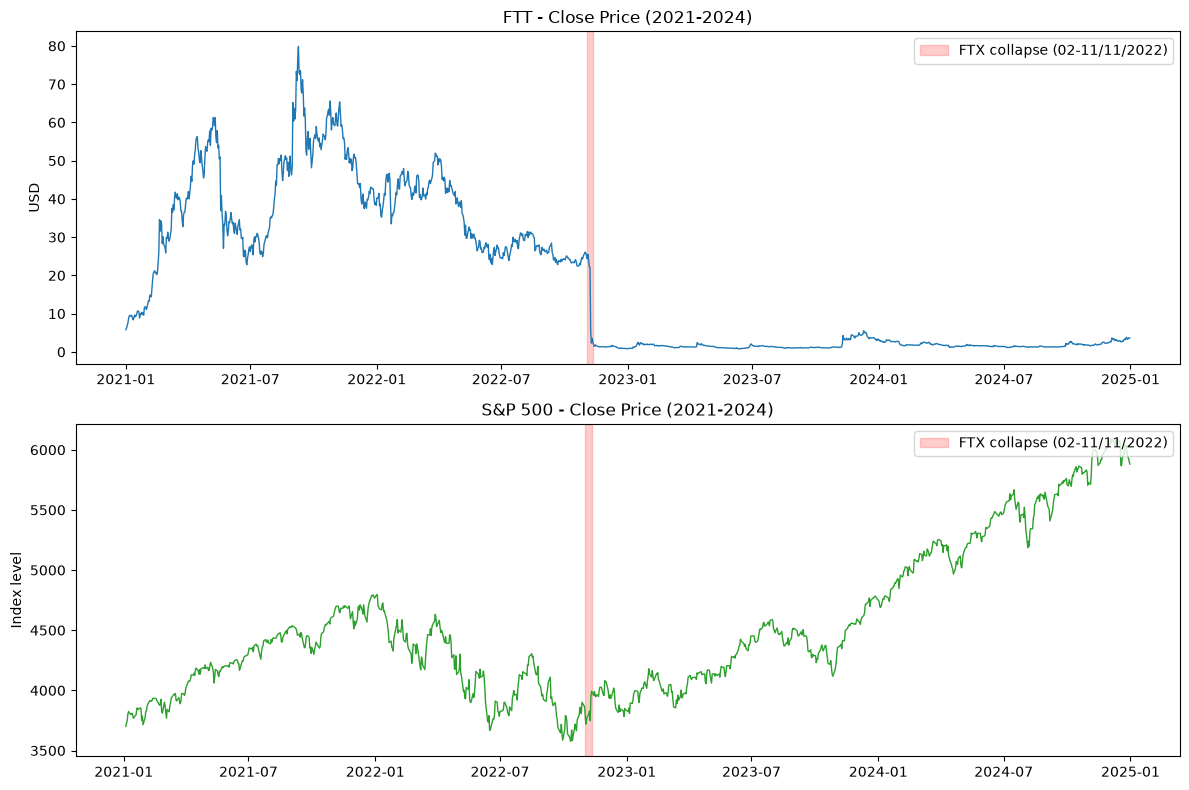

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].plot(ftt_processed["trade_date"], ftt_processed["close_price"], color="tab:blue", linewidth=1)
axes[0].axvspan(EVENT_START, EVENT_END, color="red", alpha=0.2, label="FTX collapse (02-11/11/2022)")
axes[0].set_title("FTT - Close Price (2021-2024)")
axes[0].set_ylabel("USD")
axes[0].legend(loc="upper right")

axes[1].plot(sp500_processed["trade_date"], sp500_processed["close_price"], color="tab:green", linewidth=1)
axes[1].axvspan(EVENT_START, EVENT_END, color="red", alpha=0.2, label="FTX collapse (02-11/11/2022)")
axes[1].set_title("S&P 500 - Close Price (2021-2024)")
axes[1].set_ylabel("Index level")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 2. Time series log return

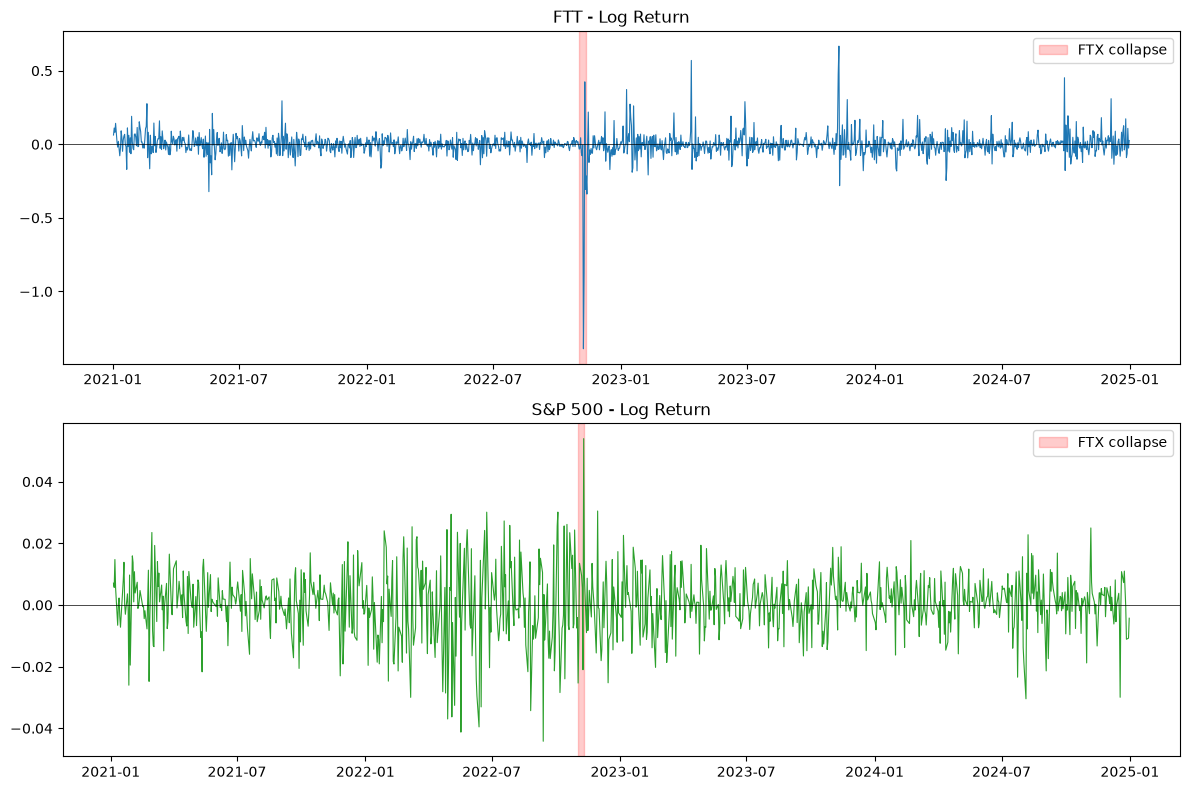

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].plot(ftt_processed["trade_date"], ftt_processed["FTT_log_return"], color="tab:blue", linewidth=0.8)
axes[0].axvspan(EVENT_START, EVENT_END, color="red", alpha=0.2, label="FTX collapse")
axes[0].axhline(0, color="black", linewidth=0.5)
axes[0].set_title("FTT - Log Return")
axes[0].legend(loc="upper right")

axes[1].plot(sp500_processed["trade_date"], sp500_processed["SP500_log_return"], color="tab:green", linewidth=0.8)
axes[1].axvspan(EVENT_START, EVENT_END, color="red", alpha=0.2, label="FTX collapse")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("S&P 500 - Log Return")
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

## 3. Histogram phân phối log return

,asset,n,mean,std,skew,kurtosis,min,max
0,FTT,1460,-0.000318,0.081895,-3.074843,72.017601,-1.389306,0.667133
1,S&P 500,1004,0.000461,0.010396,-0.265228,1.919890,-0.044199,0.053953


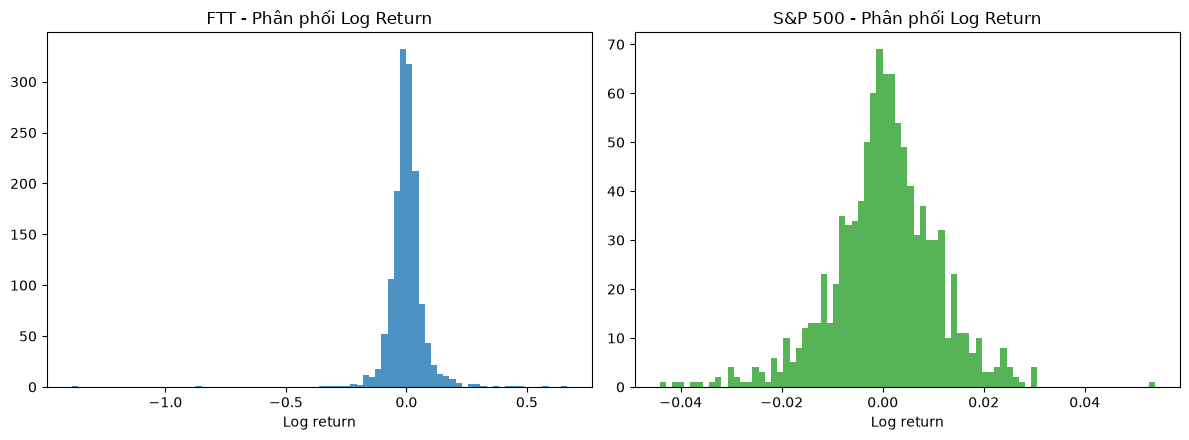

In [6]:
from scipy import stats as scipy_stats

def describe_return(series, name):
    s = series.dropna()
    return {
        "asset": name,
        "n": len(s),
        "mean": s.mean(),
        "std": s.std(),
        "skew": scipy_stats.skew(s),
        "kurtosis": scipy_stats.kurtosis(s),  # excess kurtosis (0 = normal)
        "min": s.min(),
        "max": s.max(),
    }

desc_table = pd.DataFrame([
    describe_return(ftt_processed["FTT_log_return"], "FTT"),
    describe_return(sp500_processed["SP500_log_return"], "S&P 500"),
])
display(desc_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=False)

axes[0].hist(ftt_processed["FTT_log_return"].dropna(), bins=80, color="tab:blue", alpha=0.8)
axes[0].set_title("FTT - Phân phối Log Return")
axes[0].set_xlabel("Log return")

axes[1].hist(sp500_processed["SP500_log_return"].dropna(), bins=80, color="tab:green", alpha=0.8)
axes[1].set_title("S&P 500 - Phân phối Log Return")
axes[1].set_xlabel("Log return")

plt.tight_layout()
plt.show()

## 4. Zoom vào event window

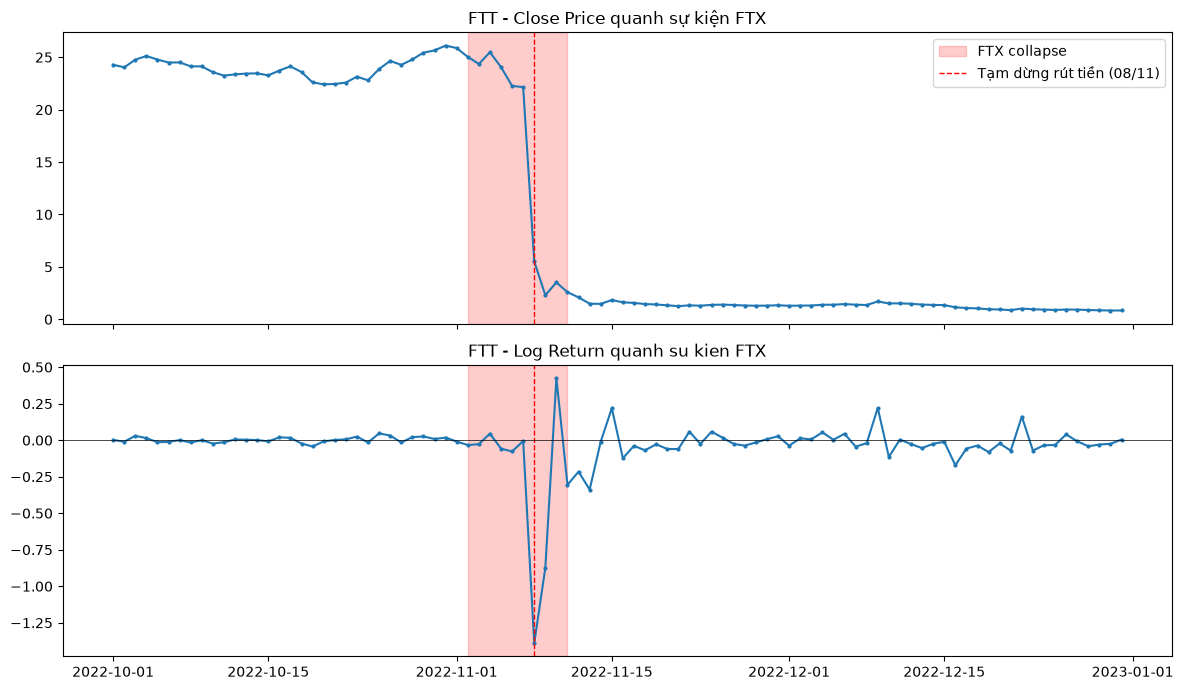

Số quan sát FTT trong event window (02-11/11/2022): 10


In [7]:
ftt_zoom = ftt_processed[(ftt_processed["trade_date"] >= VIEW_START) & (ftt_processed["trade_date"] <= VIEW_END)]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(ftt_zoom["trade_date"], ftt_zoom["close_price"], color="tab:blue", marker="o", markersize=2)
axes[0].axvspan(EVENT_START, EVENT_END, color="red", alpha=0.2, label="FTX collapse")
axes[0].axvline(EVENT_DATE, color="red", linestyle="--", linewidth=1, label="Tạm dừng rút tiền (08/11)")
axes[0].set_title("FTT - Close Price quanh sự kiện FTX")
axes[0].legend(loc="upper right")

axes[1].plot(ftt_zoom["trade_date"], ftt_zoom["FTT_log_return"], color="tab:blue", marker="o", markersize=2)
axes[1].axvspan(EVENT_START, EVENT_END, color="red", alpha=0.2)
axes[1].axvline(EVENT_DATE, color="red", linestyle="--", linewidth=1)
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("FTT - Log Return quanh su kien FTX")

plt.tight_layout()
plt.show()

n_event = len(ftt_processed[(ftt_processed["trade_date"] >= EVENT_START) & (ftt_processed["trade_date"] <= EVENT_END)])
print("Số quan sát FTT trong event window (02-11/11/2022):", n_event)

## Kết luận trực quan hóa

1. **Chuỗi giá (Close Price):**

   * **FTT:** Giá FTT có sự thay đổi cấu trúc rõ rệt sau khủng hoảng tháng 11/2022. Giá giảm hơn 90%, từ khoảng **$25 USD** xuống vùng **$1-$3 USD** và không quay lại mức giá trước khủng hoảng. Điều này cho thấy chuỗi giá không có xu hướng trở về mức trung bình lịch sử.
   * **S&P 500:** Không ghi nhận biến động bất thường trong thời điểm FTX sụp đổ, cho thấy sự kiện này chủ yếu ảnh hưởng đến hệ sinh thái crypto và không tạo tác động rõ rệt lên thị trường chứng khoán truyền thống.

2. **Chuỗi tỷ suất sinh lợi (Log Return):**

   * Log Return giúp loại bỏ xu hướng dài hạn của giá, đưa lợi suất của cả hai tài sản dao động quanh mức **0 ($\mu \approx 0$)**.
   * FTT xuất hiện **cụm biến động (Volatility Clustering)** rõ rệt trong và sau khủng hoảng, với nhiều phiên biến động mạnh liên tiếp. Điều này cho thấy phương sai của FTT thay đổi theo thời gian.

3. **Đặc điểm phân phối lợi suất:**

   * FTT có **Kurtosis = 72.0176** và **Skew = -3.0748**, cho thấy phân phối lệch trái và khác xa phân phối chuẩn.
   * FTT có hiện tượng **đuôi béo (Fat-tails)**, đặc biệt ở phía lợi suất âm, cho thấy khả năng xuất hiện các biến động giảm mạnh cao hơn so với phân phối chuẩn.

**→** Những kết quả trên là cơ sở để thực hiện các kiểm định **ACF và ADF** nhằm kiểm tra tính dừng của chuỗi giá và chuỗi lợi suất, đồng thời xác định bậc tích hợp của dữ liệu.
